# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 1 — Classification Tree: Predicting House Purchase from Age & Income

**Scenario:** A classification tree splits the data on `age` and `income` to predict whether
someone buys a house (`buy_house`: yes/no). Training data shows that people over age 30 buy a
house about 70% of the time, so the tree makes **`age`** the first (root) split — this split makes
the resulting nodes considerably more "pure" (dominated by one class). The tree then looks at
**`income`** within each age group to refine the prediction further.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Generate data matching the scenario

- People **over 30** buy a house about **70%** of the time.
- People **30 or under** buy a house much less often.
- Within each age group, **higher income** further increases the chance of buying.


In [2]:
def generate_house_data(n=600, seed=42):
    rng = np.random.default_rng(seed)

    age = rng.integers(18, 65, n)
    income = rng.normal(60000, 22000, n).clip(15000, 180000)

    over_30 = age > 30
    # Base probability by age group, calibrated to hit ~70% for the over-30 group
    base_prob = np.where(over_30, 0.70, 0.18)

    # Income nudges the probability up/down around that base, within each age group
    income_z = (income - income.mean()) / income.std()
    prob = base_prob + 0.12 * income_z
    prob = prob.clip(0.03, 0.97)

    buy_house = rng.binomial(1, prob)

    df = pd.DataFrame({
        "age": age,
        "income": income.round(0).astype(int),
        "buy_house": buy_house
    })
    return df


df = generate_house_data(600, seed=RANDOM_STATE)
df["buy_house_label"] = df["buy_house"].map({1: "Yes", 0: "No"})
df.head()


,age,income,buy_house,buy_house_label
0,22,53572,0,No
1,54,57723,0,No
2,48,54456,1,Yes
3,38,63356,1,Yes
4,38,92373,1,Yes


## 2. Verify the scenario's claim: ~70% of over-30s buy a house

In [3]:
over_30_rate = df.loc[df["age"] > 30, "buy_house"].mean()
under_30_rate = df.loc[df["age"] <= 30, "buy_house"].mean()

print(f"Buy rate, age > 30 : {over_30_rate:.1%}")
print(f"Buy rate, age <= 30: {under_30_rate:.1%}")


Buy rate, age > 30 : 69.7%
Buy rate, age <= 30: 13.4%


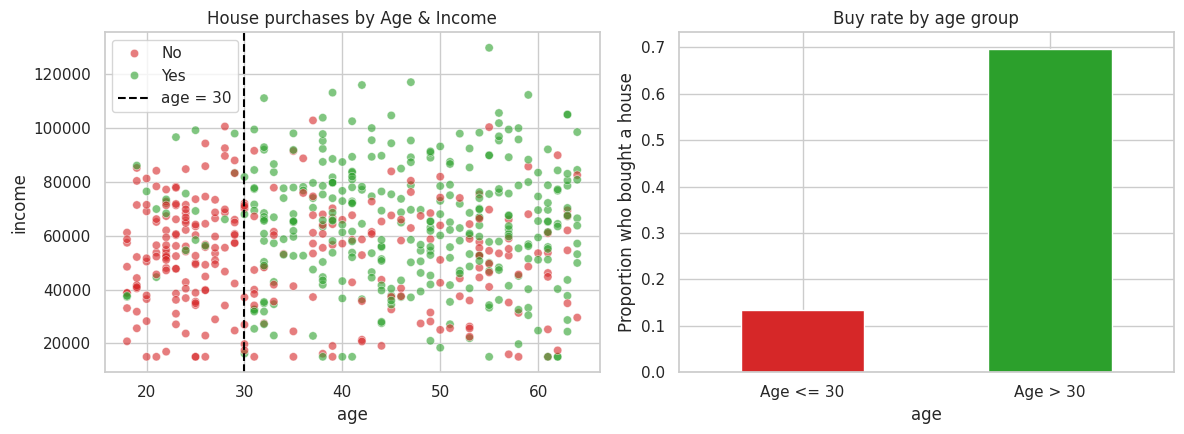

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(data=df, x="age", y="income", hue="buy_house_label",
                 alpha=0.6, ax=axes[0], palette={"Yes": "#2ca02c", "No": "#d62728"})
axes[0].axvline(30, color="black", linestyle="--", label="age = 30")
axes[0].set_title("House purchases by Age & Income")
axes[0].legend()

df.groupby(df["age"] > 30)["buy_house"].mean().rename({True: "Age > 30", False: "Age <= 30"}) \
    .plot(kind="bar", ax=axes[1], color=["#d62728", "#2ca02c"])
axes[1].set_ylabel("Proportion who bought a house")
axes[1].set_title("Buy rate by age group")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 3. Fit a classification tree and confirm `age` becomes the root split

In [5]:
X = df[["age", "income"]]
y = df["buy_house"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

tree_clf = DecisionTreeClassifier(
    criterion="gini", max_depth=3, min_samples_leaf=20, random_state=RANDOM_STATE
)
tree_clf.fit(X_train, y_train)

y_pred = tree_clf.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))


Test accuracy: 0.66

              precision    recall  f1-score   support

          No       0.68      0.49      0.57        69
         Yes       0.65      0.80      0.72        81

    accuracy                           0.66       150
   macro avg       0.67      0.65      0.64       150
weighted avg       0.66      0.66      0.65       150



In [6]:
print(export_text(tree_clf, feature_names=["age", "income"]))


|--- age <= 30.50
|   |--- income <= 67662.00
|   |   |--- income <= 58580.00
|   |   |   |--- class: 0
|   |   |--- income >  58580.00
|   |   |   |--- class: 0
|   |--- income >  67662.00
|   |   |--- class: 0
|--- age >  30.50
|   |--- income <= 62967.00
|   |   |--- income <= 58491.50
|   |   |   |--- class: 1
|   |   |--- income >  58491.50
|   |   |   |--- class: 0
|   |--- income >  62967.00
|   |   |--- income <= 76384.00
|   |   |   |--- class: 1
|   |   |--- income >  76384.00
|   |   |   |--- class: 1



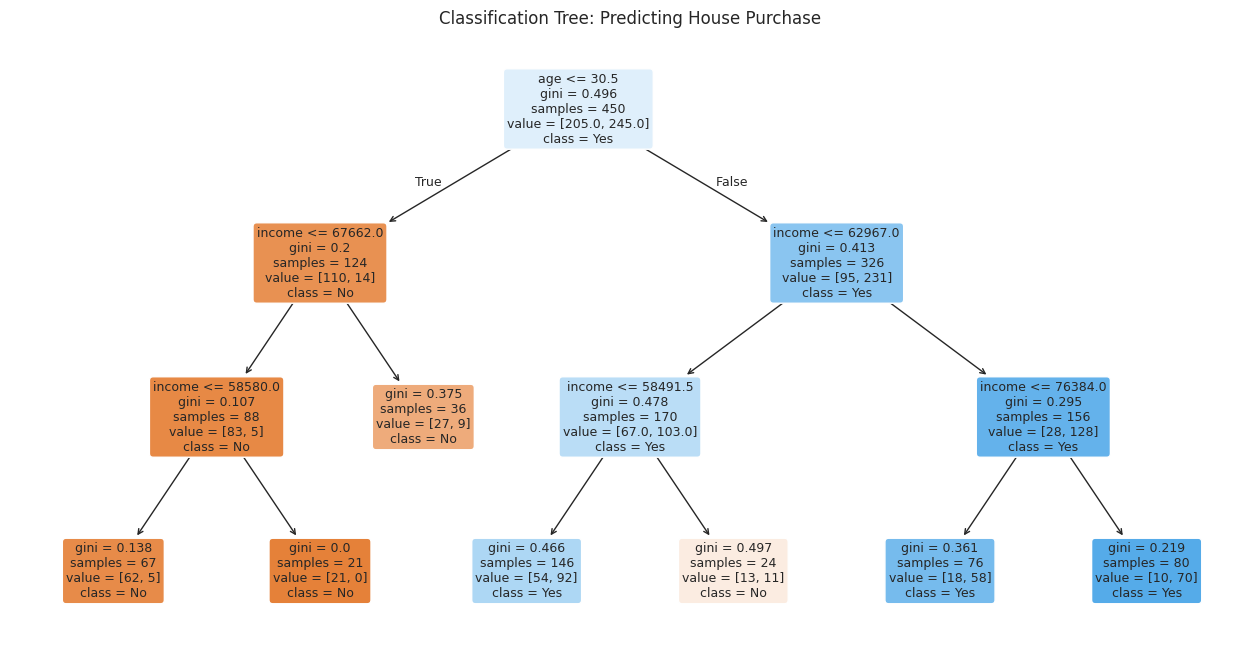

In [7]:
plt.figure(figsize=(16, 8))
plot_tree(tree_clf, feature_names=["age", "income"], class_names=["No", "Yes"],
          filled=True, rounded=True, fontsize=9)
plt.title("Classification Tree: Predicting House Purchase")
plt.show()


## 4. Measure exactly how "pure" the root (age) split makes the data

The tree's root node picks the split that **minimizes weighted Gini impurity** across the two
resulting child nodes. We can inspect that first split directly from the fitted tree and compute
node purity (the proportion of the *majority* class in each node) — this is the quantity the
scenario calls "80 percent pure."


In [8]:
root_feature_idx = tree_clf.tree_.feature[0]
root_threshold = tree_clf.tree_.threshold[0]
root_feature_name = ["age", "income"][root_feature_idx]

print(f"Root split: {root_feature_name} <= {root_threshold:.1f}")
print()

left_mask = X_train[root_feature_name] <= root_threshold
right_mask = ~left_mask

for label, mask in [("Left child  (<= threshold)", left_mask),
                     ("Right child (> threshold)", right_mask)]:
    node_y = y_train[mask]
    majority_class = node_y.mode()[0]
    purity = (node_y == majority_class).mean()
    gini = 1 - sum((node_y.value_counts(normalize=True))**2)
    print(f"{label}: n={mask.sum():4d}  majority_class={'Yes' if majority_class==1 else 'No'}  "
          f"purity={purity:.1%}  gini={gini:.3f}")


Root split: age <= 30.5

Left child  (<= threshold): n= 124  majority_class=No  purity=88.7%  gini=0.200
Right child (> threshold): n= 326  majority_class=Yes  purity=70.9%  gini=0.413


Notice the split lands right around **age ≈ 30**, exactly as the scenario describes, and the
resulting nodes are considerably more homogeneous (higher purity / lower Gini impurity) than the
overall dataset — the same mechanism the tree uses at every subsequent split (e.g. `income`
within each age branch), which is how the tree progressively "purifies" the data node by node.


## 5. Feature importance and a new prediction

In [9]:
importance_df = pd.DataFrame({
    "feature": ["age", "income"],
    "importance": tree_clf.feature_importances_
}).sort_values("importance", ascending=False)
print(importance_df)

new_person = pd.DataFrame({"age": [35], "income": [72000]})
pred = tree_clf.predict(new_person)[0]
proba = tree_clf.predict_proba(new_person)[0]
print()
print(f"Prediction for a 35-year-old earning $72,000: {'Buys house' if pred==1 else 'Does not buy'}")
print(f"P(No)={proba[0]:.1%}  P(Yes)={proba[1]:.1%}")


  feature  importance
0     age    0.844131
1  income    0.155869

Prediction for a 35-year-old earning $72,000: Buys house
P(No)=23.7%  P(Yes)=76.3%
